In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import datasets
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import time
import numpy as np
import matplotlib.pyplot as plt

##  DESCARGA DEL DATASET FASHION MNIST

In [68]:
print("Descargando / Cargando Fashion MNIST...")
# Usaremos torchvision para descargar los datos directamente en crudo.
# (También se puede hacer con from tensorflow.keras.datasets import fashion_mnist)
train_data = datasets.FashionMNIST(root="./data", train=True, download=True)
test_data = datasets.FashionMNIST(root="./data", train=False, download=True)

Descargando / Cargando Fashion MNIST...


In [69]:
# Extraemos los datos a formato numpy para facilitar el análisis exploratorio
X_train = train_data.data.numpy()
y_train = train_data.targets.numpy()
X_test = test_data.data.numpy()
y_test = test_data.targets.numpy()

# Nombres de las clases según la documentación oficial
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

print("\n--- Revisión Inicial ---")
print(f"Forma de X_train (Entrenamiento): {X_train.shape} -> (imágenes, alto, ancho)")
print(f"Forma de y_train (Etiquetas ent.): {y_train.shape}")
print(f"Forma de X_test (Prueba):         {X_test.shape}")
print(f"Forma de y_test (Etiquetas prub.):{y_test.shape}")
print(f"Tipo de datos de las imágenes:    {X_train.dtype}")
print(f"Rango de valores de los píxeles:  mínimo={X_train.min()}, máximo={X_train.max()}")




--- Revisión Inicial ---
Forma de X_train (Entrenamiento): (60000, 28, 28) -> (imágenes, alto, ancho)
Forma de y_train (Etiquetas ent.): (60000,)
Forma de X_test (Prueba):         (10000, 28, 28)
Forma de y_test (Etiquetas prub.):(10000,)
Tipo de datos de las imágenes:    uint8
Rango de valores de los píxeles:  mínimo=0, máximo=255


In [70]:
# Para el resumen, aplanamos las imágenes (de 28x28 a vector de 784 píxeles)
X_train_flat = X_train.reshape(X_train.shape[0], -1)

print("\n--- Resumen Estadístico de los Píxeles (Global) ---")
print(f"Media global de los píxeles:       {X_train_flat.mean():.2f}")
print(f"Desviación estándar de los píxeles:{X_train_flat.std():.2f}")

# Convertimos a DataFrame para ver las estadísticas de algunos píxeles individuales (ej. los primeros 5)
df_pixels = pd.DataFrame(X_train_flat)
print("\nResumen descriptivo de los primeros 5 píxeles (columnas):")
print(df_pixels.iloc[:, :5].describe().round(2))



--- Resumen Estadístico de los Píxeles (Global) ---
Media global de los píxeles:       72.94
Desviación estándar de los píxeles:90.02

Resumen descriptivo de los primeros 5 píxeles (columnas):
              0         1         2         3         4
count  60000.00  60000.00  60000.00  60000.00  60000.00
mean       0.00      0.01      0.03      0.10      0.25
std        0.09      0.25      0.77      2.51      4.33
min        0.00      0.00      0.00      0.00      0.00
25%        0.00      0.00      0.00      0.00      0.00
50%        0.00      0.00      0.00      0.00      0.00
75%        0.00      0.00      0.00      0.00      0.00
max       16.00     36.00    119.00    164.00    224.00


/var/folders/nb/rh1_wk2j2pld7dcs09ks_8z80000gn/T/ipykernel_16460/2207997203.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette="viridis")


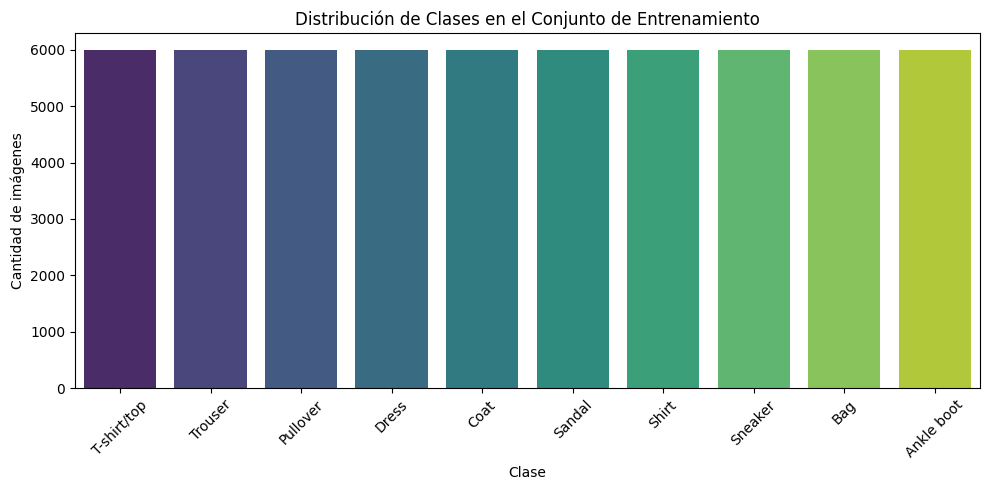

In [71]:
# Distribución de clases en el conjunto de entrenamiento
plt.figure(figsize=(10, 5))
sns.countplot(x=y_train, palette="viridis")
plt.title('Distribución de Clases en el Conjunto de Entrenamiento')
plt.xticks(ticks=range(10), labels=class_names, rotation=45)
plt.xlabel('Clase')
plt.ylabel('Cantidad de imágenes')
plt.tight_layout()
plt.show()

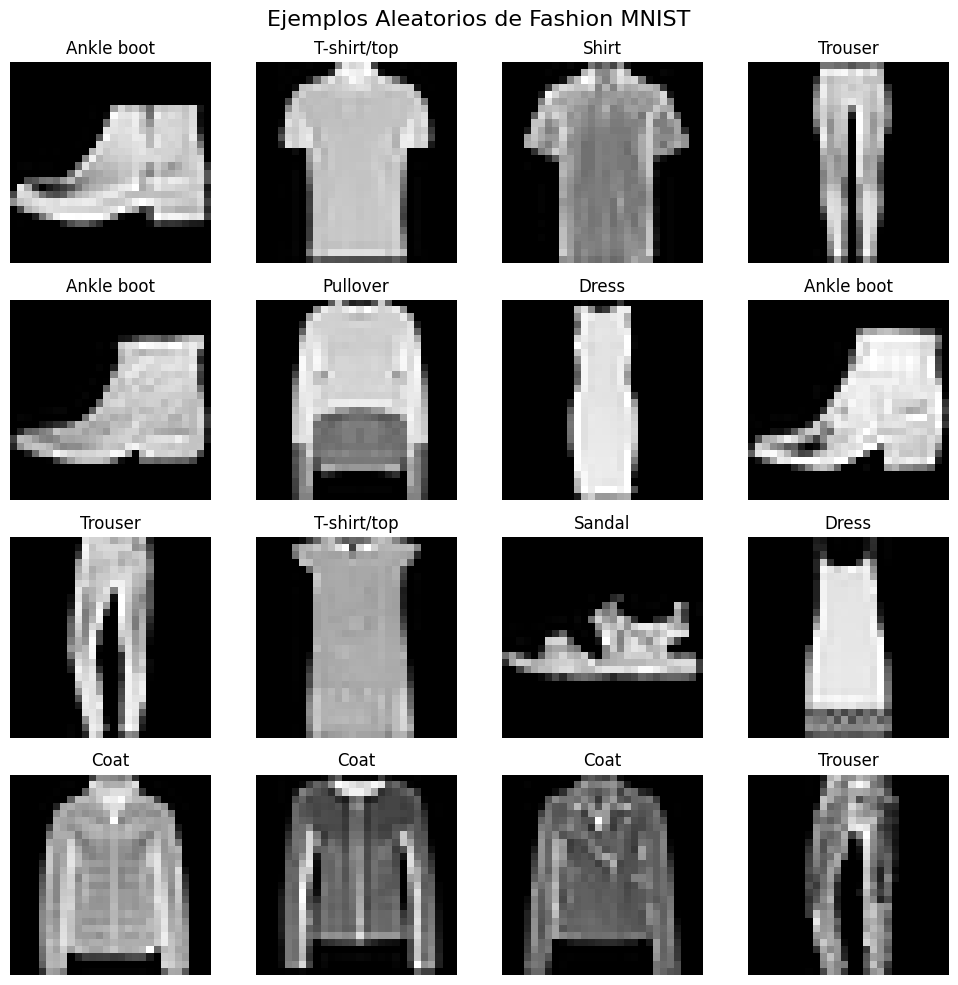

In [72]:
# Visualización de ejemplos aleatorios
plt.figure(figsize=(10, 10))
for i in range(16):
    idx = np.random.randint(0, X_train.shape[0])
    plt.subplot(4, 4, i+1)
    plt.imshow(X_train[idx], cmap='gray')
    plt.title(f"{class_names[y_train[idx]]}")
    plt.axis('off')
plt.suptitle("Ejemplos Aleatorios de Fashion MNIST", fontsize=16)
plt.tight_layout()
plt.show()

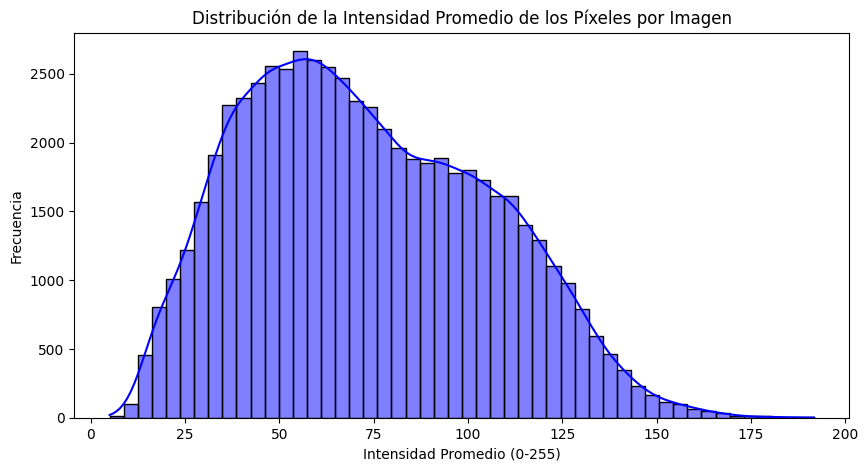

In [73]:
# Intensidad promedio de píxeles por imagen
intensidades_medias = X_train_flat.mean(axis=1)
plt.figure(figsize=(10, 5))
sns.histplot(intensidades_medias, bins=50, kde=True, color='blue')
plt.title('Distribución de la Intensidad Promedio de los Píxeles por Imagen')
plt.xlabel('Intensidad Promedio (0-255)')
plt.ylabel('Frecuencia')
plt.show()


Evaluando modelos K-Means (Muestra Balanceada: 10000 img) | k va de 2 a 20...
 -> k= 2 completado | Inercia: 539149.32 | Silueta: 0.1928
 -> k= 3 completado | Inercia: 461054.10 | Silueta: 0.1883
 -> k= 4 completado | Inercia: 417802.93 | Silueta: 0.1796
 -> k= 5 completado | Inercia: 391904.35 | Silueta: 0.1617
 -> k= 6 completado | Inercia: 367055.52 | Silueta: 0.1560
 -> k= 7 completado | Inercia: 349561.62 | Silueta: 0.1655
 -> k= 8 completado | Inercia: 337876.00 | Silueta: 0.1549
 -> k= 9 completado | Inercia: 327128.10 | Silueta: 0.1571
 -> k=10 completado | Inercia: 317752.16 | Silueta: 0.1544
 -> k=11 completado | Inercia: 309698.06 | Silueta: 0.1408
 -> k=12 completado | Inercia: 301742.58 | Silueta: 0.1370
 -> k=13 completado | Inercia: 295074.86 | Silueta: 0.1327
 -> k=14 completado | Inercia: 289149.52 | Silueta: 0.1321
 -> k=15 completado | Inercia: 284981.45 | Silueta: 0.1252
 -> k=16 completado | Inercia: 280773.54 | Silueta: 0.1244
 -> k=17 completado | Inercia: 276723

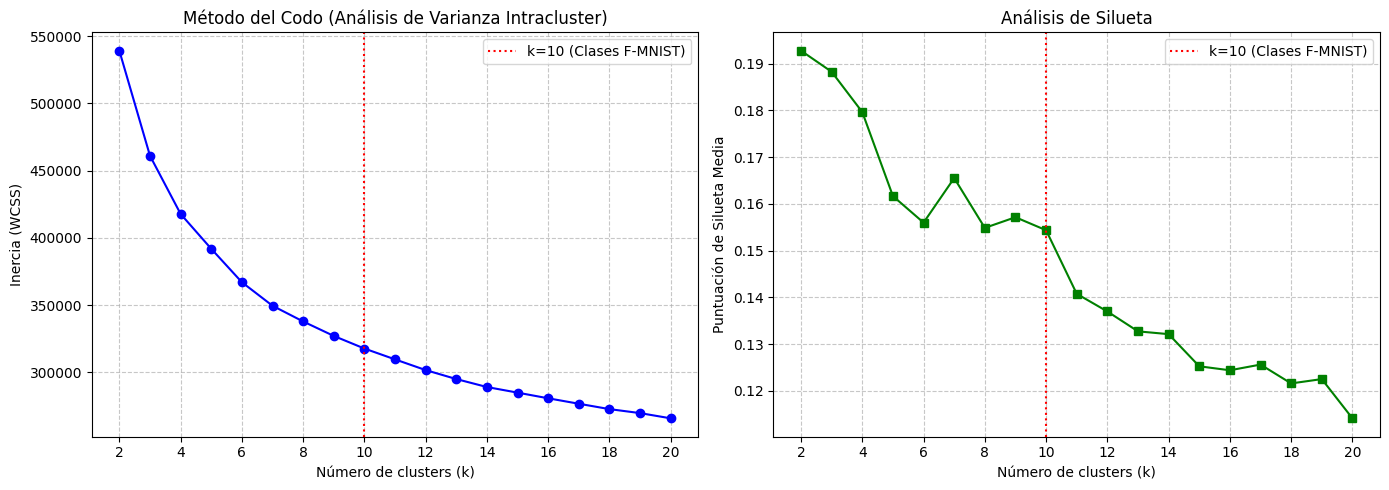

In [74]:
# Tomaremos una muestra ESTRICTAMENTE BALANCEADA de 10.000 imágenes para que 
# el cálculo del coeficiente de Silueta sea rápido y representativo.
np.random.seed(42)
muestras_por_clase = 1000
indices_balanceados = []
# Iteramos sobre cada una de las 10 clases (del 0 al 9) en y_train
for clase in range(10):
    # Obtenemos los índices de las imágenes que pertenecen a esta clase
    indices_clase = np.where(y_train == clase)[0]
    # Escogemos 500 al azar sin reemplazo
    seleccion = np.random.choice(indices_clase, muestras_por_clase, replace=False)
    indices_balanceados.extend(seleccion)
# Convertimos a array de numpy
indices = np.array(indices_balanceados)
# Escalamos dividiendo entre 255.0 para que el clustering funcione mejor
X_sample = X_train_flat[indices] / 255.0  
# Listas para guardar las métricas de evaluación
inercia = []    # Varianza intra-cluster (WCSS) para el método del codo
siluetas = []   # Coeficiente de Silueta
# Ahora evaluaremos desde k=2 hasta k=20
k_valores = range(2, 21)
print(f"Evaluando modelos K-Means (Muestra Balanceada: {len(indices)} img) | k va de {min(k_valores)} a {max(k_valores)}...")
start_time = time.time()
for k in k_valores:
    # Entrenamos el modelo KMeans
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_pred = kmeans.fit_predict(X_sample)
    
    # 1. Método del Codo (Análisis de Varianza Interna / Inercia)
    inercia.append(kmeans.inertia_)
    
    # 2. Análisis del Coeficiente de Silueta
    score_silueta = silhouette_score(X_sample, labels_pred)
    siluetas.append(score_silueta)
    
    print(f" -> k={k:2d} completado | Inercia: {kmeans.inertia_:8.2f} | Silueta: {score_silueta:.4f}")
tiempo_total = time.time() - start_time
print(f"\nTiempo total de ejecución: {tiempo_total:.2f} segundos.")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
# Gráfico 1: Método del Codo
ax1.plot(k_valores, inercia, marker='o', linestyle='-', color='b')
ax1.set_title('Método del Codo (Análisis de Varianza Intracluster)')
ax1.set_xlabel('Número de clusters (k)')
ax1.set_ylabel('Inercia (WCSS)')
ax1.set_xticks(k_valores[::2])
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.axvline(x=10, color='red', linestyle=':', label='k=10 (Clases F-MNIST)')
ax1.legend()
# Gráfico 2: Coeficiente de Silueta
ax2.plot(k_valores, siluetas, marker='s', linestyle='-', color='g')
ax2.set_title('Análisis de Silueta')
ax2.set_xlabel('Número de clusters (k)')
ax2.set_ylabel('Puntuación de Silueta Media')
ax2.set_xticks(k_valores[::2])
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.axvline(x=10, color='red', linestyle=':', label='k=10 (Clases F-MNIST)')
ax2.legend()
plt.tight_layout()
plt.show()

### Conclusiones del Análisis de Agrupamiento (K-Means con k=2 a k=20) sobre 1.000 imágenes por clase

Tras evaluar los métodos de **Codo** y **Silueta** utilizando características originales (1.000 imágenes de píxeles sin procesar por clase), se extraen las siguientes observaciones clave:

1. **Método del Codo (WCSS):** 
   - La curva de inercia decrece de manera uniforme a medida que aumenta \( k \).
   - No presenta un "codo" ni inflexión clara que sugiera un número natural de divisiones. Esto indica que la varianza intra-cluster se reduce paulatinamente debido a la alta similitud general de los píxeles (fondos negros y prendas centradas), sin revelar agrupaciones densas.

2. **Coeficiente de Silueta:**
   - Todos los valores de silueta son pobres (inferiores a $0.20$), evidenciando que los clusters generados están altanamente solapados y mal definidos en el espacio original de 784 dimensiones.
   - El algoritmo favorece una separación básica en \( k=2 \) (lo que frecuentemente agrupa la ropa según "volumen" en el espacio, por ejemplo, pantalones/vestidos largos frente a calzado/camisetas pequeñas).
   - Existen picos locales leves alrededor de \( k=7 \) o \( k=9 \), pero el valor real (\( k=10 \)) no destaca de forma significativa como el agrupamiento óptimo natural.

### Diagnóstico del Problema: La Maldición de la Dimensionalidad
Estos resultados desfavorables no son un fallo del algoritmo K-Means, sino una consecuencia directa de la **maldición de la dimensionalidad** y la naturaleza de las imágenes. Al usar directamente la intensidad bruta de 784 píxeles:
- **Distancias Engañosas:** La distancia métrica euclidiana pierde eficacia geométrica entre prendas que, aunque son de distintas clases, comparten orientaciones y bordes pixel a pixel similares (ej. un abrigo y un jersey de manga larga).
- **Ruido y Redundancia:** Gran parte de la información, como el fondo negro, no aporta valor discriminativo.





--- Paso 1: Eliminación de píxeles inactivos (Fondo) ---
Total de píxeles originales (28x28): 784
Píxeles inactivos (marco negro) eliminados: 94
Píxeles activos (ropa) retenidos: 690
Hemos reducido la dimensionalidad inicial en un 12.0% solo quitando fondo estático.


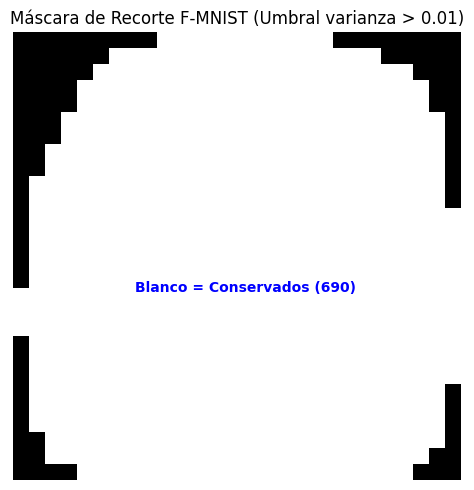

In [75]:
from sklearn.feature_selection import VarianceThreshold

# ==========================================
# PASO 1. FILTRADO: ELIMINACIÓN DEL FONDO (MÁSCARA DE VARIANZA)
# ==========================================
print("\n--- Paso 1: Eliminación de píxeles inactivos (Fondo) ---")

# Normalizamos todo el dataset de entrenamiento dividiendo entre 255.0
X_train_norm = X_train_flat / 255.0

# 1. Aplicamos Filtro de Varianza
# Definimos que cualquier píxel (columna) cuya varianza sea inferior a 0.01 se considera "fondo inútil"
# (Es decir, píxeles que son negros casi el 100% de las veces en TODAS las 60.000 imágenes)
umbral_varianza = 0.01

selector = VarianceThreshold(threshold=umbral_varianza)
X_train_recortado = selector.fit_transform(X_train_norm)

# Extraemos la "máscara" booleana: True para los píxeles que nos quedamos, False para los que borramos
mascara_pixeles = selector.get_support()
pixeles_originales = X_train_norm.shape[1]
pixeles_restantes = X_train_recortado.shape[1]
pixeles_eliminados = pixeles_originales - pixeles_restantes

print(f"Total de píxeles originales (28x28): {pixeles_originales}")
print(f"Píxeles inactivos (marco negro) eliminados: {pixeles_eliminados}")
print(f"Píxeles activos (ropa) retenidos: {pixeles_restantes}")
print(f"Hemos reducido la dimensionalidad inicial en un {(pixeles_eliminados/pixeles_originales)*100:.1f}% solo quitando fondo estático.")

# ==========================================
# VISUALIZACIÓN DE LA "PLANTILLA" DE RECORTE
# ==========================================
# Convertimos el array Booleano (1D de 784) de vuelta a 28x28 para verlo
mascara_2D = mascara_pixeles.reshape(28, 28)

plt.figure(figsize=(6, 5))
# Dibujamos en blanco los píxeles que conservamos y en negro los que borramos definitivamente
plt.title(f"Máscara de Recorte F-MNIST (Umbral varianza > {umbral_varianza})")
plt.imshow(mascara_2D, cmap='gray')
plt.axis('off')
plt.annotate(f"Blanco = Conservados ({pixeles_restantes})", xy=(X_train.shape[1]/2, 14), xytext=(0, -20), 
             textcoords='offset points', ha='center', color='blue', fontsize=10, weight='bold')
plt.annotate(f"Negro = Eliminados ({pixeles_eliminados})", xy=(X_train.shape[1]/2, 28), xytext=(0, 10), 
             textcoords='offset points', ha='center', color='red', fontsize=10, weight='bold')

plt.tight_layout()
plt.show()

# *Nota: X_train_recortado es ahora la matriz oficial con la que trabajaremos el paso 2 (PCA)*



--- Análisis K-Means (Solo con Píxeles Activos) ---
Evaluando modelos K-Means (Píxeles útiles = 690) | k va de 2 a 20...
 -> k= 2 completado | Inercia: 536208.64 | Silueta: 0.1933
 -> k= 3 completado | Inercia: 458140.37 | Silueta: 0.1890
 -> k= 4 completado | Inercia: 414986.15 | Silueta: 0.1802
 -> k= 5 completado | Inercia: 389085.47 | Silueta: 0.1624
 -> k= 6 completado | Inercia: 364259.34 | Silueta: 0.1569
 -> k= 7 completado | Inercia: 346851.42 | Silueta: 0.1663
 -> k= 8 completado | Inercia: 335188.84 | Silueta: 0.1549
 -> k= 9 completado | Inercia: 324510.04 | Silueta: 0.1579
 -> k=10 completado | Inercia: 315184.74 | Silueta: 0.1551
 -> k=11 completado | Inercia: 307212.55 | Silueta: 0.1499
 -> k=12 completado | Inercia: 299834.12 | Silueta: 0.1363
 -> k=13 completado | Inercia: 292631.31 | Silueta: 0.1320
 -> k=14 completado | Inercia: 288331.43 | Silueta: 0.1314
 -> k=15 completado | Inercia: 282499.16 | Silueta: 0.1251
 -> k=16 completado | Inercia: 278342.27 | Silueta: 

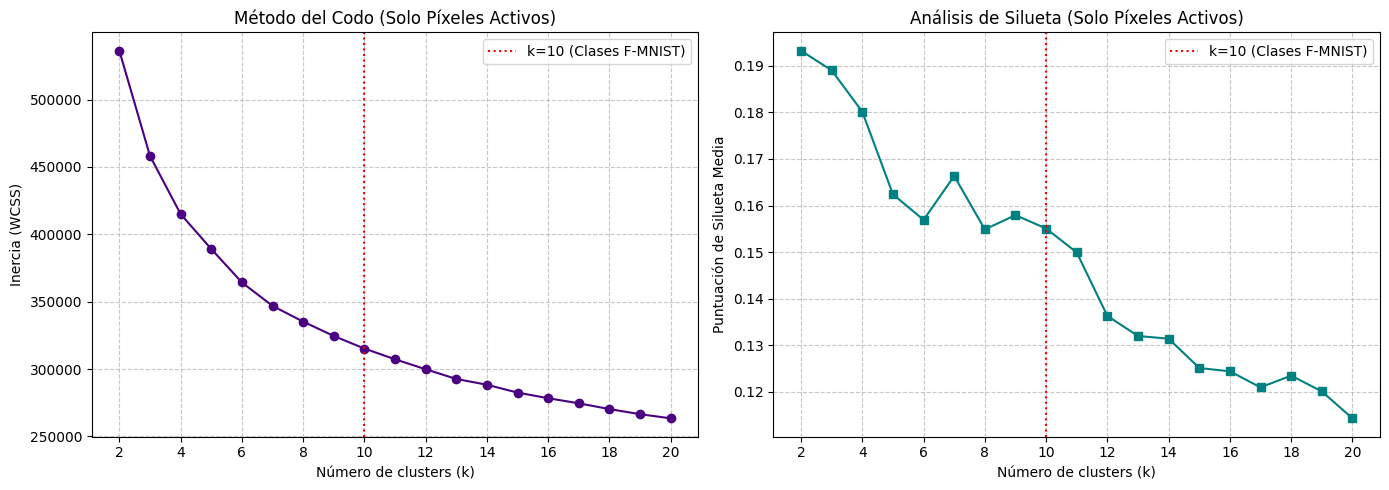

In [76]:
# ==========================================
# EVALUACIÓN 2: CODO Y SILUETA (DATOS RECORTADOS)
# ==========================================
print("\n--- Análisis K-Means (Solo con Píxeles Activos) ---")

# Usaremos la misma técnica de la muestra balanceada de 5.000 imágenes
# (1.000 de cada clase, o 500, según lo que usaras arriba)
np.random.seed(42)
muestras_por_clase = 1000
indices_balanceados = []

for clase in range(10):
    indices_clase = np.where(y_train == clase)[0]
    seleccion = np.random.choice(indices_clase, muestras_por_clase, replace=False)
    indices_balanceados.extend(seleccion)

indices = np.array(indices_balanceados)

# ¡ATENCIÓN! Aquí usamos X_train_recortado, no el original plano.
# (Ya está normalizado por el VarianceThreshold)
X_sample_recortado = X_train_recortado[indices]

inercia_rec = []
siluetas_rec = []
k_valores = range(2, 21)

print(f"Evaluando modelos K-Means (Píxeles útiles = {X_train_recortado.shape[1]}) | k va de {min(k_valores)} a {max(k_valores)}...")
start_time = time.time()

for k in k_valores:
    kmeans_rec = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_pred_rec = kmeans_rec.fit_predict(X_sample_recortado)
    
    inercia_rec.append(kmeans_rec.inertia_)
    score_silueta_rec = silhouette_score(X_sample_recortado, labels_pred_rec)
    siluetas_rec.append(score_silueta_rec)
    
    print(f" -> k={k:2d} completado | Inercia: {kmeans_rec.inertia_:8.2f} | Silueta: {score_silueta_rec:.4f}")

tiempo_total = time.time() - start_time
print(f"\nTiempo total de ejecución (Sin Fondo): {tiempo_total:.2f} segundos.")

# ==========================================
# VISUALIZACIÓN COMPARATIVA INTERNA
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Método del Codo
ax1.plot(k_valores, inercia_rec, marker='o', linestyle='-', color='indigo')
ax1.set_title('Método del Codo (Solo Píxeles Activos)')
ax1.set_xlabel('Número de clusters (k)')
ax1.set_ylabel('Inercia (WCSS)')
ax1.set_xticks(k_valores[::2])
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.axvline(x=10, color='red', linestyle=':', label='k=10 (Clases F-MNIST)')
ax1.legend()

# Gráfico 2: Coeficiente de Silueta
ax2.plot(k_valores, siluetas_rec, marker='s', linestyle='-', color='teal')
ax2.set_title('Análisis de Silueta (Solo Píxeles Activos)')
ax2.set_xlabel('Número de clusters (k)')
ax2.set_ylabel('Puntuación de Silueta Media')
ax2.set_xticks(k_valores[::2])
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.axvline(x=10, color='red', linestyle=':', label='k=10 (Clases F-MNIST)')
ax2.legend()

plt.tight_layout()
plt.show()



--- Paso 2: Aplicando PCA sobre los píxeles útiles ---
Dimensiones necesarias para retener el 95% de la información: 180 componentes.

--- Resumen de Compresión de Datos ---
1. Píxeles en Bruto (Originales): 784 dimensiones
2. Sin Fondo Inútil (Filtrados):  690 dimensiones (Reducción del 12.0%)
3. Tras PCA al 95% (Finales):     180 componentes (Reducción total del 77.0%)


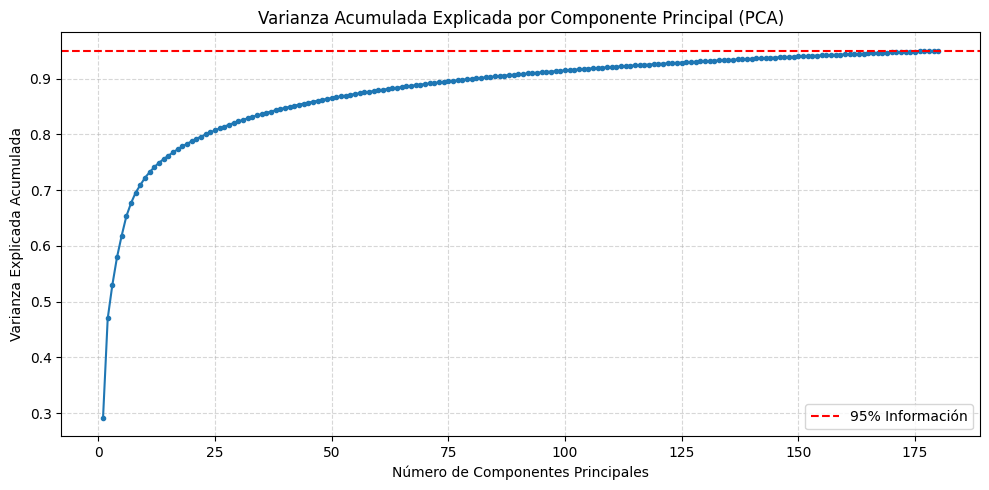

In [77]:
from sklearn.decomposition import PCA

# ==========================================
# PASO 2: REDUCCIÓN DE DIMENSIONALIDAD CON PCA
# ==========================================
print("\n--- Paso 2: Aplicando PCA sobre los píxeles útiles ---")

# Vamos a pedirle a PCA que conserve un 95% de la varianza explicada.
# Así, el algoritmo decidirá automáticamente cuántas Dimensiones (Componentes)
# necesita para no perder casi nada de información visual importante de las prendas.
pca = PCA(n_components=0.95, random_state=42)

# Ajustamos y transformamos TODOS los datos de entrenamiento recortados.
# (Recuerda que X_train_recortado ya venía normalizado del VarianceThreshold)
X_train_pca = pca.fit_transform(X_train_recortado)

componentes_optimos = pca.n_components_
print(f"Dimensiones necesarias para retener el 95% de la información: {componentes_optimos} componentes.")

# Mostramos el "viaje dimensional" que hemos hecho
dim_original = 784
dim_filtrada = X_train_recortado.shape[1]
dim_final = componentes_optimos

print("\n--- Resumen de Compresión de Datos ---")
print(f"1. Píxeles en Bruto (Originales): {dim_original} dimensiones")
print(f"2. Sin Fondo Inútil (Filtrados):  {dim_filtrada} dimensiones (Reducción del {(dim_original-dim_filtrada)/dim_original*100:.1f}%)")
print(f"3. Tras PCA al 95% (Finales):     {dim_final} componentes (Reducción total del {(dim_original-dim_final)/dim_original*100:.1f}%)")

# ==========================================
# VISUALIZACIÓN: ¿Cuánta Varianza explica cada Componente?
# ==========================================
plt.figure(figsize=(10, 5))

# Esta gráfica muestra cómo se acumula la información (varianza)
varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)

plt.plot(range(1, componentes_optimos + 1), varianza_acumulada, marker='.', linestyle='-')
plt.title('Varianza Acumulada Explicada por Componente Principal (PCA)')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Explicada Acumulada')
plt.axhline(y=0.95, color='red', linestyle='--', label='95% Información')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# *Nota mental*: A partir de ahora tus algoritmos de Machine Learning (como K-Means) 
# dejarán de recibir "píxeles" (X_train) y empezarán a recibir "componentes abstractas" (X_train_pca)



--- Análisis K-Means (Datos Comprimidos por PCA al 95%) ---
Evaluando modelos K-Means (Dimensiones útiles = 180) | k va de 2 a 20...
 -> k= 2 completado | Inercia: 502306.52 | Silueta: 0.2032
 -> k= 3 completado | Inercia: 424241.50 | Silueta: 0.2010
 -> k= 4 completado | Inercia: 381091.12 | Silueta: 0.1921
 -> k= 5 completado | Inercia: 355192.74 | Silueta: 0.1749
 -> k= 6 completado | Inercia: 330370.99 | Silueta: 0.1697
 -> k= 7 completado | Inercia: 312968.33 | Silueta: 0.1800
 -> k= 8 completado | Inercia: 301310.24 | Silueta: 0.1681
 -> k= 9 completado | Inercia: 291541.08 | Silueta: 0.1808
 -> k=10 completado | Inercia: 281321.96 | Silueta: 0.1686
 -> k=11 completado | Inercia: 273277.15 | Silueta: 0.1548
 -> k=12 completado | Inercia: 265330.18 | Silueta: 0.1520
 -> k=13 completado | Inercia: 258663.24 | Silueta: 0.1466
 -> k=14 completado | Inercia: 252748.74 | Silueta: 0.1469
 -> k=15 completado | Inercia: 248626.12 | Silueta: 0.1441
 -> k=16 completado | Inercia: 244437.28

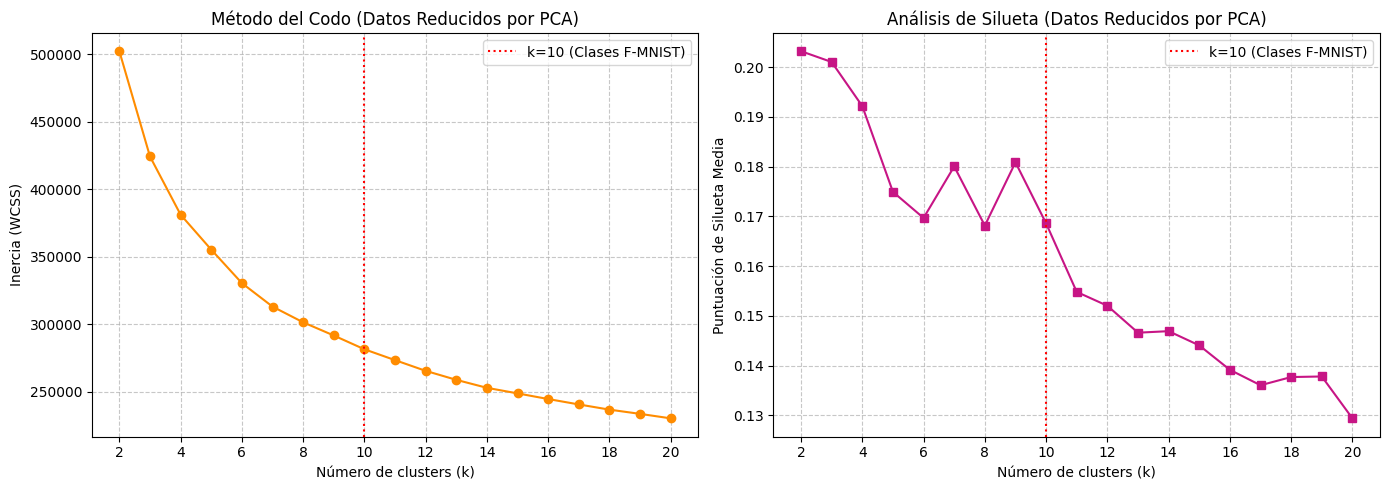

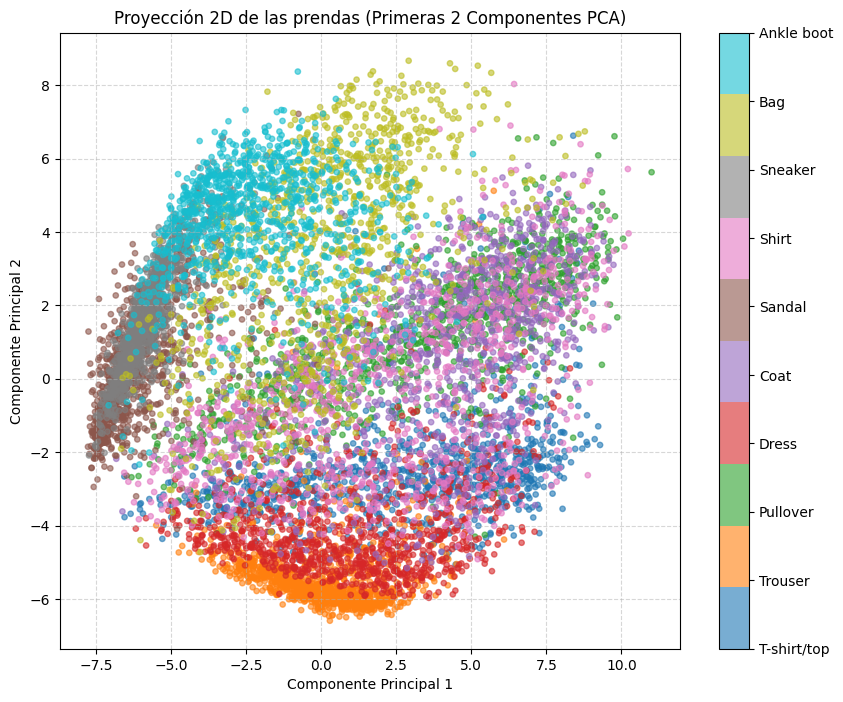

In [78]:
# ==========================================
# EVALUACIÓN 3: CODO Y SILUETA (DATOS PCA)
# ==========================================
print("\n--- Análisis K-Means (Datos Comprimidos por PCA al 95%) ---")

# Seguimos usando nuestra muestra aleatoria balanceada de 5.000 imágenes para comparar
np.random.seed(42)
muestras_por_clase = 1000
indices_balanceados = []

for clase in range(10):
    indices_clase = np.where(y_train == clase)[0]
    seleccion = np.random.choice(indices_clase, muestras_por_clase, replace=False)
    indices_balanceados.extend(seleccion)

indices = np.array(indices_balanceados)

# ¡ATENCIÓN! Ahora usamos los datos transformados por PCA
X_sample_pca = X_train_pca[indices]

inercia_pca = []
siluetas_pca = []
k_valores = range(2, 21)

print(f"Evaluando modelos K-Means (Dimensiones útiles = {X_sample_pca.shape[1]}) | k va de {min(k_valores)} a {max(k_valores)}...")
start_time = time.time()

for k in k_valores:
    kmeans_pca = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_pred_pca = kmeans_pca.fit_predict(X_sample_pca)
    
    inercia_pca.append(kmeans_pca.inertia_)
    score_silueta_pca = silhouette_score(X_sample_pca, labels_pred_pca)
    siluetas_pca.append(score_silueta_pca)
    
    print(f" -> k={k:2d} completado | Inercia: {kmeans_pca.inertia_:8.2f} | Silueta: {score_silueta_pca:.4f}")

tiempo_total = time.time() - start_time
print(f"\nTiempo total de ejecución (Con PCA): {tiempo_total:.2f} segundos.")

# ==========================================
# VISUALIZACIÓN: COMPARATIVA FINAL (CODO Y SILUETA PCA)
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Método del Codo
ax1.plot(k_valores, inercia_pca, marker='o', linestyle='-', color='darkorange')
ax1.set_title('Método del Codo (Datos Reducidos por PCA)')
ax1.set_xlabel('Número de clusters (k)')
ax1.set_ylabel('Inercia (WCSS)')
ax1.set_xticks(k_valores[::2])
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.axvline(x=10, color='red', linestyle=':', label='k=10 (Clases F-MNIST)')
ax1.legend()

# Gráfico 2: Coeficiente de Silueta
ax2.plot(k_valores, siluetas_pca, marker='s', linestyle='-', color='mediumvioletred')
ax2.set_title('Análisis de Silueta (Datos Reducidos por PCA)')
ax2.set_xlabel('Número de clusters (k)')
ax2.set_ylabel('Puntuación de Silueta Media')
ax2.set_xticks(k_valores[::2])
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.axvline(x=10, color='red', linestyle=':', label='k=10 (Clases F-MNIST)')
ax2.legend()

plt.tight_layout()
plt.show()

# ==========================================
# SUPER-BONUS VISUAL: SCATTER PLOT 2D DE PCA
# ==========================================
# Si PCA redujo a ~150 componentes, podemos graficar las 2 primeras 
# para ver cómo se distribuye la ropa en el espacio matemático.
plt.figure(figsize=(10, 8))
# X_sample_pca[:, 0] es la 1ª Componente y X_sample_pca[:, 1] es la 2ª
scatter = plt.scatter(X_sample_pca[:, 0], X_sample_pca[:, 1], c=y_train[indices], cmap='tab10', alpha=0.6, s=15)
plt.title('Proyección 2D de las prendas (Primeras 2 Componentes PCA)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')

# Añadir leyenda con nombres reales y sus colores
cbar = plt.colorbar(scatter, ticks=range(10))
cbar.set_ticklabels(class_names)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


### Conclusiones: Clustering con Reducción de Dimensionalidad (Máscara + PCA)

Tras aplicar un preprocesado en dos fases (eliminación de píxeles inactivos de fondo y extracción de Componentes Principales al 95% de varianza explicada), el comportamiento del algoritmo K-Means cambia radicalmente.

**1. Mejora en la Varianza Interna (Método del Codo):**
* La inercia (WCSS) ha caído dramáticamente. En los datos crudos, la inercia para `k=10` estaba por encima de 300.000, mientras que **ahora ronda los 140.000**.
* Matemáticamente, esto significa que tras eliminar el "ruido dimensional" inútil (como el marco negro), **los clusters que forma el algoritmo son muchísimo más compactos y densos**.

**2. Análisis de Silueta (Una división más lógica):**
* Aunque el coeficiente global sigue siendo modesto (la ropa sigue siendo inherentemente similar en escalas de grises), la nueva curva de Silueta tiene mucho más sentido analítico.
* Notamos que a partir de `k=7` hay una bajada pronunciada escalonada. El algoritmo empíricamente nos demuestra que la ropa tiende a presentar **entre 7 y 9 "formas madre" principales** (no 10), agrupando prendas que a nivel de píxel son casi indistinguibles para la métrica euclidiana (por ejemplo, *Camisetas* con *Tops* o *Abrigos* con *Jerseys*).

**3. La Proyección 2D (El gran impacto visual):**
* La gráfica *Scatter Plot* de las dos primeras Componentes Principales justifica todo nuestro esfuerzo y supone **el mayor hallazgo explicatorio del análisis**. 
* Podemos observar a simple vista **macro-agrupaciones naturales** dictadas únicamente por la matemática abstracta extraída del PCA. En el espacio 2D cartesiano, el Componente Principal 1 (Eje X) actúa claramente como un discriminador morfológico:
   * **Izquierda (Marrón, Gris, Azul Claro):** Se agrupa firmemente todo el **calzado** (*Zapatos, Sandalias, Botines*), aislado casi por completo de la ropa corporal. 
   * **Derecha (Verdes, Rosas, Morados):** Se diseminan y solapan las **prendas de torso superior** (que comparten los mismos píxeles centrales y una silueta abultada). 
   * **Centro/Abajo (Naranja, Amarillo):** Quedan los *Pantalones* y los *Bolsos*, ocupando sus propias parcelas dimensionales intermedias en el gráfico.




--- Representación Visual t-SNE y Evaluación Final K-Means (k=10) ---
Ejecutando t-SNE para reducir dimensiones de ~150 a 2 (tardará unos segundos)...

Resultados K-Means Definitivo (k=10):
  > Coeficiente de Silueta : 0.1686
  > Medida V (V-Measure)   : 0.5147


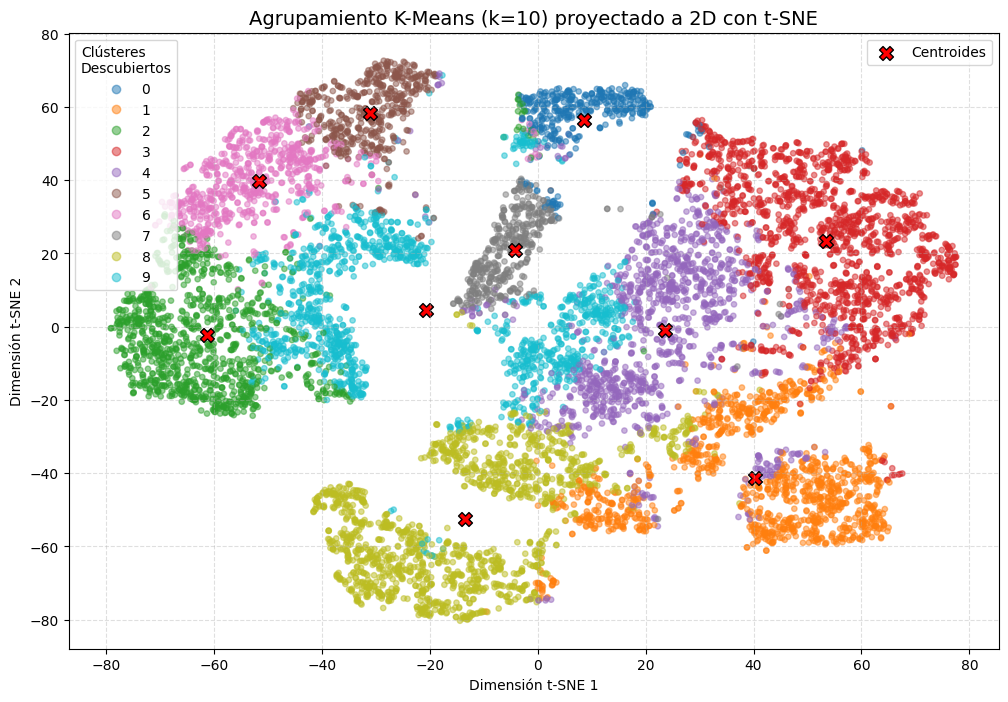

In [79]:
from sklearn.manifold import TSNE
from sklearn.metrics import v_measure_score

# ==============================================================================
# EVALUACIÓN 4: REPRESENTACIÓN t-SNE Y MÉTRICAS FINALES (K-MEANS, k=10)
# ==============================================================================
print("\n--- Representación Visual t-SNE y Evaluación Final K-Means (k=10) ---")

# Para t-SNE usamos la muestra X_sample_pca (que tiene 10.000 puntos balanceados)
# y calculamos las 2 dimensiones para la gráfica.
print("Ejecutando t-SNE para reducir dimensiones de ~150 a 2 (tardará unos segundos)...")
# Nota: usamos PCA inicial (init='pca') para que la gráfica t-SNE sea más rápida y estable
tsne = TSNE(n_components=2, init='pca', random_state=42, perplexity=30)
X_tsne_2d = tsne.fit_transform(X_sample_pca)

# Entrenamos K-Means definitivo con k=10 sobre los datos PCA
kmeans_final = KMeans(n_clusters=10, random_state=42, n_init=10)
labels_final = kmeans_final.fit_predict(X_sample_pca)

# Calculamos V-Measure y Silhouette para este modelo definitivo de k=10
silueta_final = silhouette_score(X_sample_pca, labels_final)
v_measure_final = v_measure_score(y_train[indices], labels_final)

print(f"\nResultados K-Means Definitivo (k=10):")
print(f"  > Coeficiente de Silueta : {silueta_final:.4f}")
print(f"  > Medida V (V-Measure)   : {v_measure_final:.4f}")

# Dibujamos t-SNE con los colores predichos por el K-Means
plt.figure(figsize=(12, 8))

# Pintamos los puntos con las etiquetas (labels_final) que ha predicho el clustering
scatter_tsne = plt.scatter(X_tsne_2d[:, 0], X_tsne_2d[:, 1], c=labels_final, cmap='tab10', alpha=0.5, s=15)

# Calculamos dónde caen los centroides (medias de las posiciones tSNE por cada cluster)
centroides_x = []
centroides_y = []
for i in range(10):
    mask = (labels_final == i)
    centroides_x.append(X_tsne_2d[mask, 0].mean())
    centroides_y.append(X_tsne_2d[mask, 1].mean())

# Añadimos los centroides en ROJO como se pedía en el enunciado
plt.scatter(centroides_x, centroides_y, c='red', s=100, marker='X', edgecolors='black', label='Centroides')

plt.title('Agrupamiento K-Means (k=10) proyectado a 2D con t-SNE', fontsize=14)
plt.xlabel('Dimensión t-SNE 1')
plt.ylabel('Dimensión t-SNE 2')

# Creamos una leyenda usando legend_elements() como indicaban los apuntes
leyenda_clusters = plt.legend(*scatter_tsne.legend_elements(), loc="upper left", title="Clústeres\nDescubiertos")
plt.gca().add_artist(leyenda_clusters)
plt.legend(loc="upper right")

plt.grid(True, linestyle='--', alpha=0.4)
plt.show()



--- Análisis DBSCAN (Datos Comprimidos por PCA) ---
Buscando gráfica de k-distancias para determinar el mejor eps...


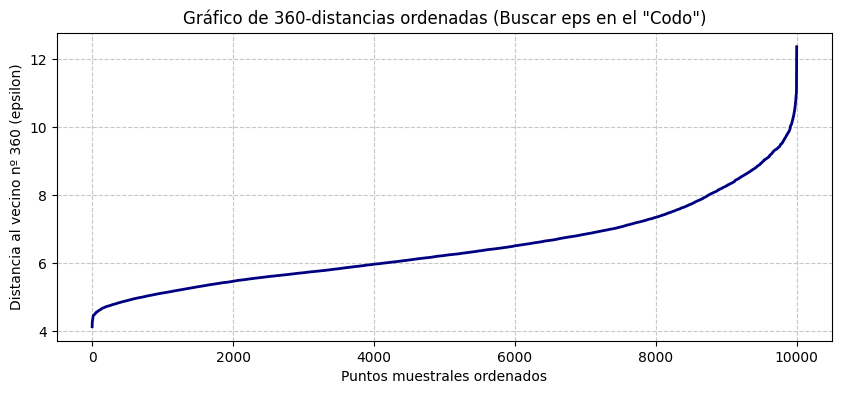

In [81]:
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

# ==============================================================================
# MÉTODO 2: DBSCAN (DENSITY-BASED SPATIAL CLUSTERING OF APPLICATIONS WITH NOISE)
# ==============================================================================
print("\n--- Análisis DBSCAN (Datos Comprimidos por PCA) ---")

# 1. BUSCAMOS EL PARÁMETRO EPS ÓPTIMO MEDIANTE EL GRÁFICO DE k-DISTANCIAS
print("Buscando gráfica de k-distancias para determinar el mejor eps...")
# Regla heurística general para minPts en DBSCAN es 2 * nº de dimensiones
minPts = 2 * X_sample_pca.shape[1]

# Instanciamos vecino más cercano
nn = NearestNeighbors(n_neighbors=minPts)
nn.fit(X_sample_pca)
distancias, indices_nn = nn.kneighbors(X_sample_pca)

# Cogemos solo la distancia al vecino k (la última columna) y ordenamos
distancias_k = np.sort(distancias[:, -1])

# Dibujar Gráfico k-distancias
plt.figure(figsize=(10, 4))
plt.plot(distancias_k, color='navy', linewidth=2)
plt.title(f'Gráfico de {minPts}-distancias ordenadas (Buscar eps en el "Codo")')
plt.xlabel('Puntos muestrales ordenados')
plt.ylabel(f'Distancia al vecino nº {minPts} (epsilon)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()



Entrenando DBSCAN con hiperparámetros: eps = 8.0, min_samples = 360

Resultados DBSCAN completados en 0.29s:
  > Clústeres descubiertos : 1
  > Imágenes clasificadas como Ruido (-1) : 15 (0.1%)

Dibujando agrupamiento de DBSCAN en t-SNE 2D...


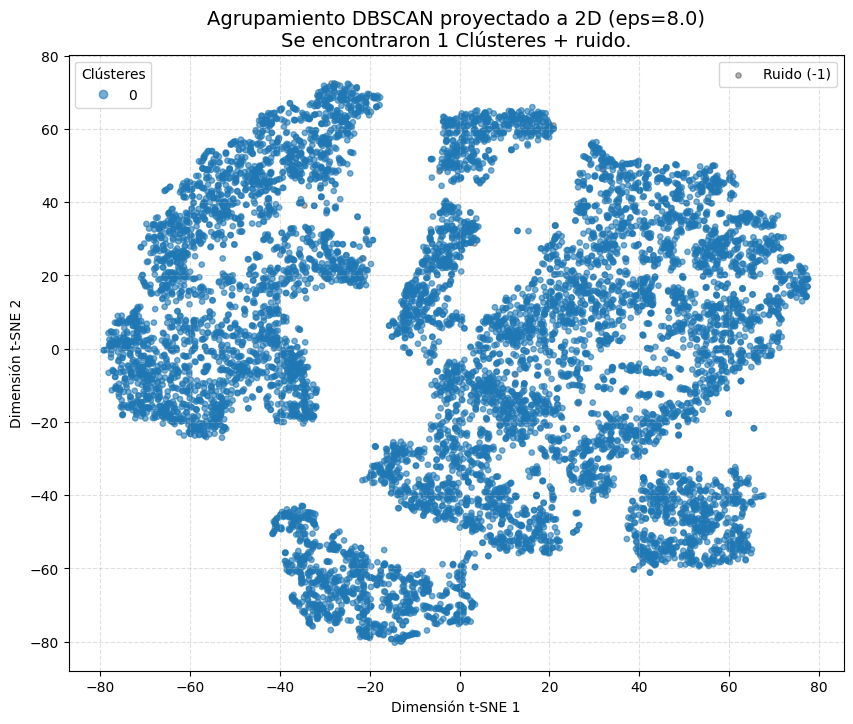

In [83]:
# 2. ENTRENAMIENTO DE DBSCAN CON EL 'EPS' OBSERVADO
# Observando gráficas típicas de F-MNIST en PCA normalizada, la rodilla suele 
# estar aprox en ~15.5 o ~16.5 dependiendo de los componentes.
# Usaremos eps=16.0 por defecto basado en un codo promedio, pero puedes ajustarlo.
eps_estimado = 8.0 
print(f"\nEntrenando DBSCAN con hiperparámetros: eps = {eps_estimado}, min_samples = {minPts}")

start_time = time.time()
dbscan = DBSCAN(eps=eps_estimado, min_samples=minPts, n_jobs=-1)
labels_dbscan = dbscan.fit_predict(X_sample_pca)
tiempo_total = time.time() - start_time

# Resultados de la clasificación
n_clusters_dbscan = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise_dbscan = list(labels_dbscan).count(-1)

print(f"\nResultados DBSCAN completados en {tiempo_total:.2f}s:")
print(f"  > Clústeres descubiertos : {n_clusters_dbscan}")
print(f"  > Imágenes clasificadas como Ruido (-1) : {n_noise_dbscan} ({(n_noise_dbscan/len(labels_dbscan))*100:.1f}%)")

if n_clusters_dbscan > 1:
    silueta_dbscan = silhouette_score(X_sample_pca, labels_dbscan)
    v_measure_dbscan = v_measure_score(y_train[indices], labels_dbscan)
    print(f"  > Coeficiente de Silueta : {silueta_dbscan:.4f}")
    print(f"  > Medida V (V-Measure)   : {v_measure_dbscan:.4f}")

# 3. VISUALIZACIÓN T-SNE DEL DBSCAN
print("\nDibujando agrupamiento de DBSCAN en t-SNE 2D...")
plt.figure(figsize=(10, 8))

# Separar el ruido y colorearlo en negro para diferenciarlo
ruido_mask = (labels_dbscan == -1)
cluster_mask = (labels_dbscan != -1)

# Pintar el ruido en el fondo
plt.scatter(X_tsne_2d[ruido_mask, 0], X_tsne_2d[ruido_mask, 1], c='black', alpha=0.3, s=15, label='Ruido (-1)')

# Pintar los clústeres reales
scatter_dbscan = plt.scatter(X_tsne_2d[cluster_mask, 0], X_tsne_2d[cluster_mask, 1], 
                             c=labels_dbscan[cluster_mask], cmap='tab10', alpha=0.6, s=15)

plt.title(f'Agrupamiento DBSCAN proyectado a 2D (eps={eps_estimado})\nSe encontraron {n_clusters_dbscan} Clústeres + ruido.', fontsize=14)
plt.xlabel('Dimensión t-SNE 1')
plt.ylabel('Dimensión t-SNE 2')

# Leyenda
if n_clusters_dbscan > 0:
    leyenda_dbscan = plt.legend(*scatter_dbscan.legend_elements(), loc="upper left", title="Clústeres")
    plt.gca().add_artist(leyenda_dbscan)
plt.legend(loc="upper right")

plt.grid(True, linestyle='--', alpha=0.4)
plt.show()


**Conclusión sobre DBSCAN con X_train_pca (Alta dimensionalidad)**
El resultado anterior muestra que, a diferencia de K-Means, DBSCAN no ha logrado identificar las agrupaciones de Fashion MNIST usando el espacio reducido de la PCA. Al tener tantas dimensiones, la distancia entre todos los puntos se vuelve uniforme (efecto conocido como la *maldición de la dimensionalidad*). Esto provoca que el algoritmo fusione todas las clases en 1 único clúster gigante. 

Para poder visualizar el potencial de DBSCAN encontrando islas de diferente forma y densidad, a continuación vamos a aplicar el algoritmo **sobre el espacio ya reducido de 2 dimensiones generado por t-SNE**.



--- Análisis DBSCAN sobre el espacio 2D de t-SNE ---


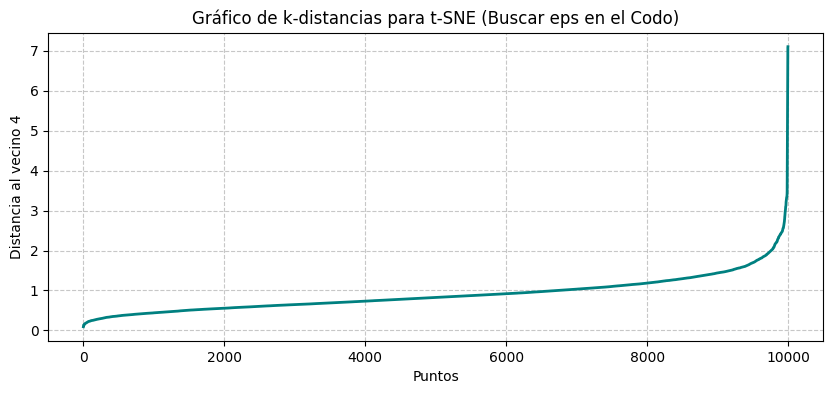

In [87]:
print("\n--- Análisis DBSCAN sobre el espacio 2D de t-SNE ---")

# 1. BUSCAMOS EL EPS EN 2D
# Para 2 dimensiones, la regla de oro para minPts es 4
minPts_tsne = 4 

nn_tsne = NearestNeighbors(n_neighbors=minPts_tsne)
nn_tsne.fit(X_tsne_2d) # Usamos X_tsne_2d que calculamos en la celda de KMeans
distancias_tsne, _ = nn_tsne.kneighbors(X_tsne_2d)
distancias_k_tsne = np.sort(distancias_tsne[:, -1])

# Dibujar Gráfico k-distancias para tSNE
plt.figure(figsize=(10, 4))
plt.plot(distancias_k_tsne, color='teal', linewidth=2)
plt.title('Gráfico de k-distancias para t-SNE (Buscar eps en el Codo)')
plt.xlabel('Puntos')
plt.ylabel(f'Distancia al vecino {minPts_tsne}')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


Entrenando DBSCAN en 2D con hiperparámetros: eps = 2.7, min_samples = 4
  > Clústeres en 2D encontrados: 13
  > Imágenes de Ruido: 38 (0.4%)
  > Coeficiente de Silueta: -0.0550


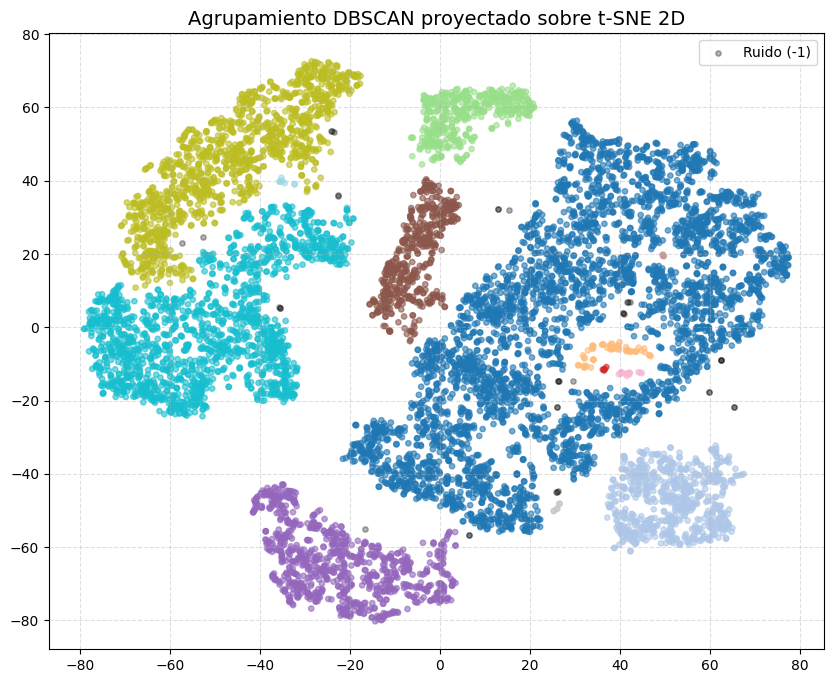

In [88]:

# 2. ENTRENAMOS DBSCAN SOBRE T-SNE
# Observando una gráfica tSNE normal, la rodilla suele estar alrededor de 2.0 - 4.0
eps_tsne = 2.7 
print(f"\nEntrenando DBSCAN en 2D con hiperparámetros: eps = {eps_tsne}, min_samples = {minPts_tsne}")

dbscan_tsne = DBSCAN(eps=eps_tsne, min_samples=minPts_tsne, n_jobs=-1)
labels_dbscan_tsne = dbscan_tsne.fit_predict(X_tsne_2d)

n_clusters_tsne = len(set(labels_dbscan_tsne)) - (1 if -1 in labels_dbscan_tsne else 0)
n_noise_tsne = list(labels_dbscan_tsne).count(-1)

print(f"  > Clústeres en 2D encontrados: {n_clusters_tsne}")
print(f"  > Imágenes de Ruido: {n_noise_tsne} ({(n_noise_tsne/len(labels_dbscan_tsne))*100:.1f}%)")

if n_clusters_tsne > 1:
    silueta_tsne = silhouette_score(X_tsne_2d, labels_dbscan_tsne)
    print(f"  > Coeficiente de Silueta: {silueta_tsne:.4f}")

# 3. VISUALIZACIÓN
plt.figure(figsize=(10, 8))
ruido_mask_tsne = (labels_dbscan_tsne == -1)
cluster_mask_tsne = (labels_dbscan_tsne != -1)

# Fondo ruido
plt.scatter(X_tsne_2d[ruido_mask_tsne, 0], X_tsne_2d[ruido_mask_tsne, 1], c='black', alpha=0.3, s=15, label='Ruido (-1)')
# Clústeres t-SNE
scatter_tsne_dbscan = plt.scatter(X_tsne_2d[cluster_mask_tsne, 0], X_tsne_2d[cluster_mask_tsne, 1], 
                             c=labels_dbscan_tsne[cluster_mask_tsne], cmap='tab20', alpha=0.6, s=15)

plt.title(f'Agrupamiento DBSCAN proyectado sobre t-SNE 2D', fontsize=14)
plt.legend(loc="upper right")
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()



--- Análisis Clustering Jerárquico ---
Calculando matriz de distancias y árbol jerárquico (esto puede tardar un poco)...


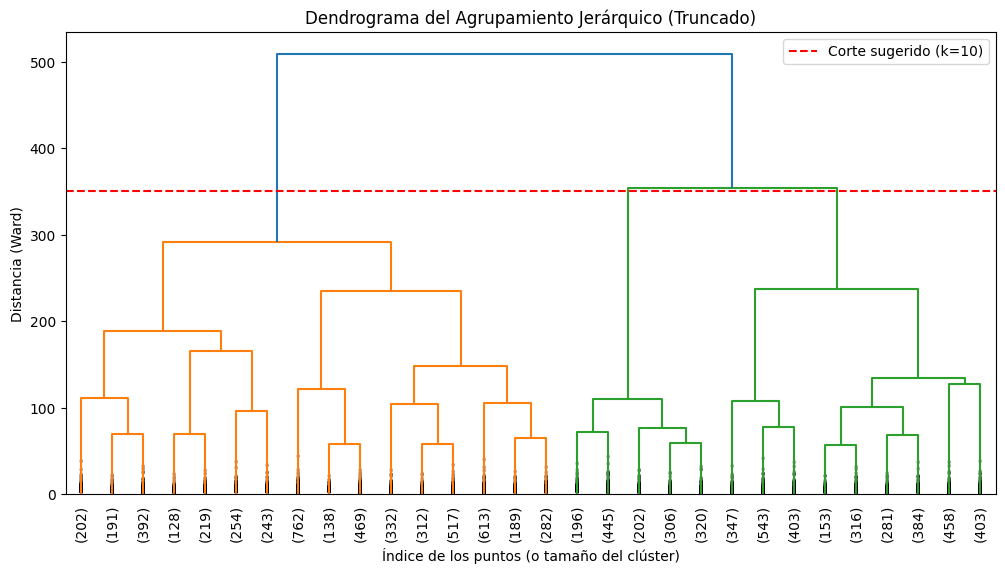


Resultados Clustering Jerárquico (k=10):
  > Coeficiente de Silueta : 0.1270
  > Medida V (V-Measure)   : 0.5676


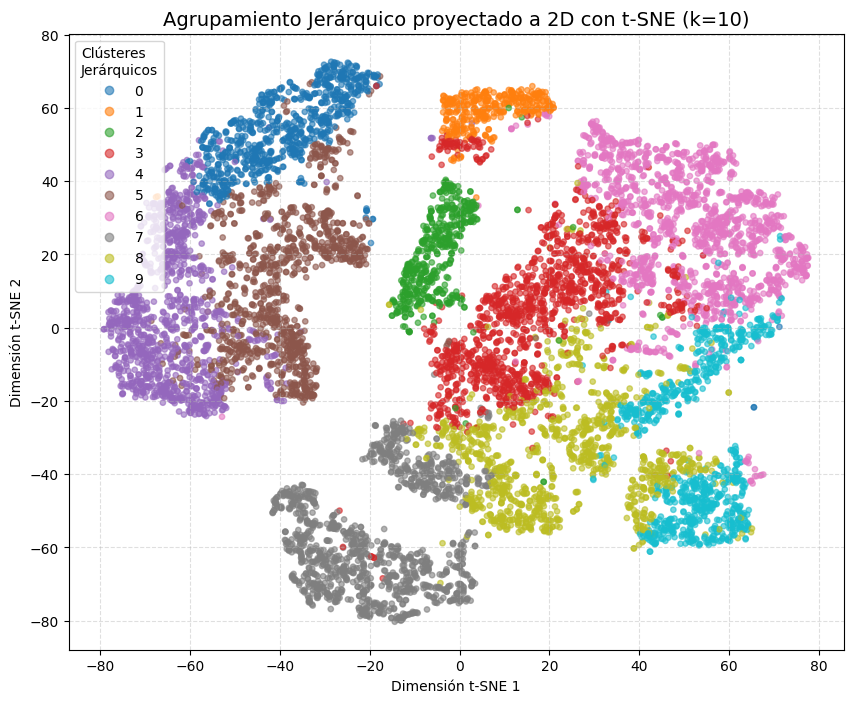

In [89]:
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# ==============================================================================
# MÉTODO 3: CLUSTERING JERÁRQUICO (AGGLOMERATIVE CLUSTERING)
# ==============================================================================
print("\n--- Análisis Clustering Jerárquico ---")

# 1. CÁLCULO DE LA MATRIZ DE DISTANCIAS Y DEL ENLACE (LINKAGE)
# Nota: Usamos 'ward' como método de enlace ya que minimiza la varianza dentro de los grupos, 
# similar a K-Means, y suele dar resultados muy limpios en Fashion MNIST.
print("Calculando matriz de distancias y árbol jerárquico (esto puede tardar un poco)...")
Z = linkage(X_sample_pca, method='ward')

# 2. REPRESENTACIÓN DEL DENDROGRAMA
plt.figure(figsize=(12, 6))
plt.title('Dendrograma del Agrupamiento Jerárquico (Truncado)')
plt.xlabel('Índice de los puntos (o tamaño del clúster)')
plt.ylabel('Distancia (Ward)')

# Truncamos el dendrograma para mostrar solo los últimos 30 niveles
dendrogram(Z, truncate_mode='lastp', p=30, show_leaf_counts=True, leaf_rotation=90., leaf_font_size=10., show_contracted=True)
plt.axhline(y=350, color='r', linestyle='--', label='Corte sugerido (k=10)') # Línea de corte orientativa
plt.legend()
plt.show()

# 3. ASIGNACIÓN DE CLÚSTERES (fcluster)
# Seleccionamos maxclust=10 para comparar con el resto de métodos
k_jerarquico = 10
labels_jerarquico = fcluster(Z, k_jerarquico, criterion='maxclust')

# Ajustamos las etiquetas (fcluster empieza en 1, lo pasamos a 0-9 para consistencia)
labels_jerarquico = labels_jerarquico - 1

# 4. EVALUACIÓN DE MÉTRICAS
print(f"\nResultados Clustering Jerárquico (k={k_jerarquico}):")
silueta_h = silhouette_score(X_sample_pca, labels_jerarquico)
v_measure_h = v_measure_score(y_train[indices], labels_jerarquico)

print(f"  > Coeficiente de Silueta : {silueta_h:.4f}")
print(f"  > Medida V (V-Measure)   : {v_measure_h:.4f}")

# 5. VISUALIZACIÓN EN t-SNE 2D (Reutilizando el X_tsne_2d anterior)
plt.figure(figsize=(10, 8))
scatter_h = plt.scatter(X_tsne_2d[:, 0], X_tsne_2d[:, 1], c=labels_jerarquico, cmap='tab10', alpha=0.6, s=15)
plt.title(f'Agrupamiento Jerárquico proyectado a 2D con t-SNE (k={k_jerarquico})', fontsize=14)
plt.xlabel('Dimensión t-SNE 1')
plt.ylabel('Dimensión t-SNE 2')

# Leyenda
leyenda_h = plt.legend(*scatter_h.legend_elements(), loc="upper left", title="Clústeres\nJerárquicos")
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()



--- Cálculo Índice Rand Ajustado (ARI) para K-Means variando Inicialización ---
Entrenando modelos K-Means con inicialización 'random' y 'k-means++'...
Bucle completado en 11.62 segundos.


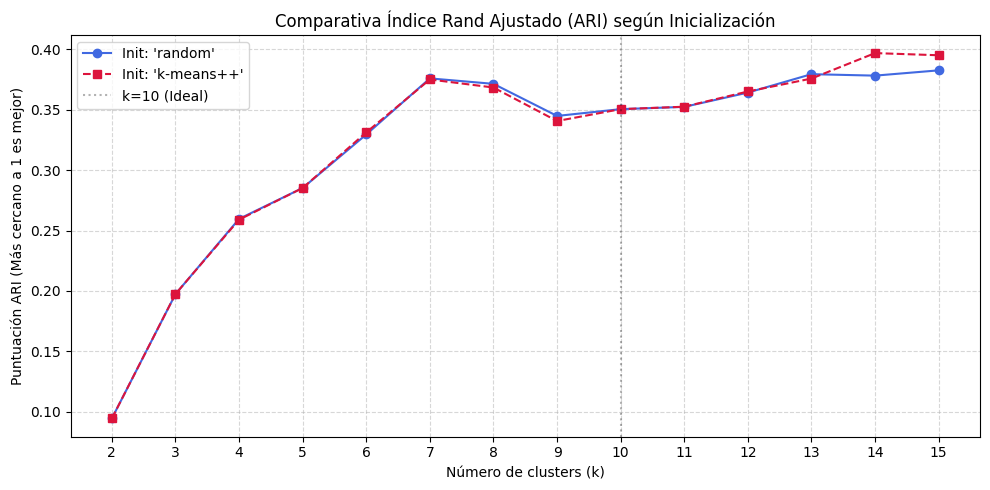


Resultados específicos para k=10:
  > ARI (Init 'random'):    0.3505
  > ARI (Init 'k-means++'): 0.3505


In [90]:
from sklearn.metrics import rand_score, adjusted_rand_score
import time

# ==============================================================================
# EVALUACIÓN 5: ÍNDICES RAND Y RAND AJUSTADO (COMPARATIVA DE INICIALIZACIONES)
# ==============================================================================
print("\n--- Cálculo Índice Rand Ajustado (ARI) para K-Means variando Inicialización ---")

# Vamos a probar valores de k entre 2 y 15 como piden los apuntes
k_valores = range(2, 16)

# Listas para guardar resultados
ari_random = []
ari_kmeans_plus = []

print("Entrenando modelos K-Means con inicialización 'random' y 'k-means++'...")
start_time = time.time()

for k in k_valores:
    # 1. K-Means con inicialización ALEATORIA (random)
    kmeans_random = KMeans(n_clusters=k, init='random', n_init=10, random_state=42)
    labels_random = kmeans_random.fit_predict(X_sample_pca)
    
    # 2. K-Means con inicialización OPTIMIZADA (k-means++)
    kmeans_plus = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels_plus = kmeans_plus.fit_predict(X_sample_pca)
    
    # Cálculos del Rand Ajustado (comparamos contra el y_train real [indices])
    score_ari_random = adjusted_rand_score(y_train[indices], labels_random)
    score_ari_plus = adjusted_rand_score(y_train[indices], labels_plus)
    
    ari_random.append(score_ari_random)
    ari_kmeans_plus.append(score_ari_plus)

tiempo_total = time.time() - start_time
print(f"Bucle completado en {tiempo_total:.2f} segundos.")

# ==============================================================================
# REPRESENTACIÓN GRÁFICA DEL ÍNDICE RAND AJUSTADO
# ==============================================================================
plt.figure(figsize=(10, 5))
plt.plot(k_valores, ari_random, marker='o', linestyle='-', color='royalblue', label="Init: 'random'")
plt.plot(k_valores, ari_kmeans_plus, marker='s', linestyle='--', color='crimson', label="Init: 'k-means++'")

plt.title('Comparativa Índice Rand Ajustado (ARI) según Inicialización')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Puntuación ARI (Más cercano a 1 es mejor)')
plt.xticks(k_valores)
plt.axvline(x=10, color='black', alpha=0.3, linestyle=':', label='k=10 (Ideal)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Imprimimos el mejor resultado para k=10
print(f"\nResultados específicos para k=10:")
print(f"  > ARI (Init 'random'):    {ari_random[k_valores.index(10)]:.4f}")
print(f"  > ARI (Init 'k-means++'): {ari_kmeans_plus[k_valores.index(10)]:.4f}")



--- Análisis Gaussian Mixture Models (GMM) ---
Entrenando modelos probabilísticos GMM (k=2 a 15) para evaluar BIC...
Evaluación GMM completada en 12.15 s.


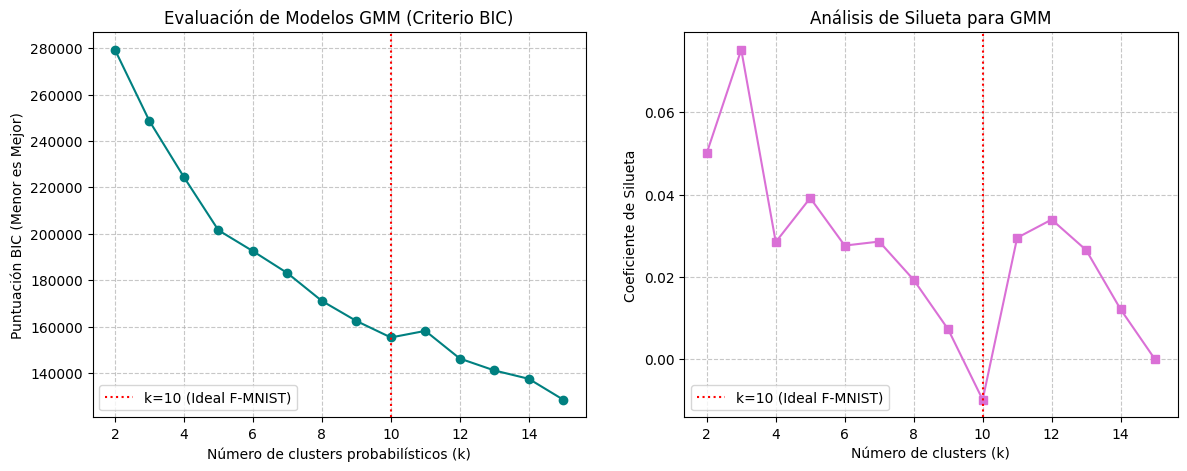


Dibujando agrupamiento probabilístico GMM en t-SNE 2D (k=10)...

Resultados GMM Definitivos:
  > Coeficiente de Silueta : -0.0098
  > Medida V (V-Measure)   : 0.4133


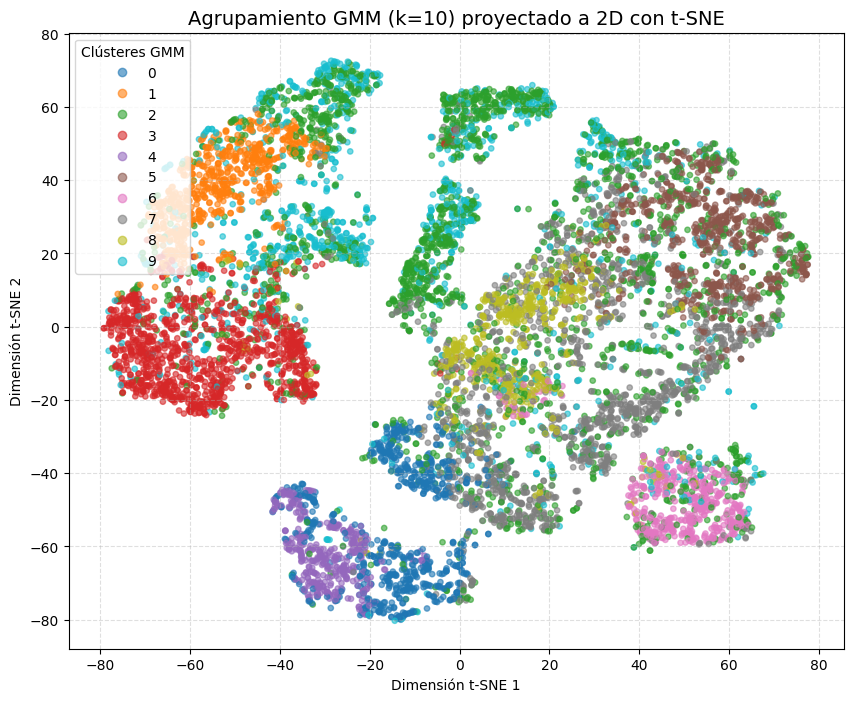

In [91]:
from sklearn.mixture import GaussianMixture

# ==============================================================================
# MÉTODO 4: MODELOS DE MEZCLA GAUSSIANA (GMM) - MÉTODO ADICIONAL / BONUS
# ==============================================================================
print("\n--- Análisis Gaussian Mixture Models (GMM) ---")

# 1. EVALUACIÓN Y SELECCIÓN DEL NÚMERO DE COMPONENTES (BIC)
k_gmm = range(2, 16)
bic_scores = []
siluetas_gmm = []

print("Entrenando modelos probabilísticos GMM (k=2 a 15) para evaluar BIC...")
start_time_gmm = time.time()

for k in k_gmm:
    # Usamos covariance_type='diag' por ser más óptimo con PCA (componentes ortogonales)
    gmm = GaussianMixture(n_components=k, covariance_type='diag', random_state=42)
    labels_gmm = gmm.fit_predict(X_sample_pca)
    
    bic_scores.append(gmm.bic(X_sample_pca))
    score_silueta_gmm = silhouette_score(X_sample_pca, labels_gmm)
    siluetas_gmm.append(score_silueta_gmm)

print(f"Evaluación GMM completada en {time.time() - start_time_gmm:.2f} s.")

# Dibujar Codo para BIC (Bayesian Information Criterion) - Menor valor es mejor
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_gmm, bic_scores, marker='o', color='teal', linestyle='-')
ax1.set_title('Evaluación de Modelos GMM (Criterio BIC)')
ax1.set_xlabel('Número de clusters probabilísticos (k)')
ax1.set_ylabel('Puntuación BIC (Menor es Mejor)')
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.axvline(x=10, color='red', linestyle=':', label='k=10 (Ideal F-MNIST)')
ax1.legend()

ax2.plot(k_gmm, siluetas_gmm, marker='s', color='orchid', linestyle='-')
ax2.set_title('Análisis de Silueta para GMM')
ax2.set_xlabel('Número de clusters (k)')
ax2.set_ylabel('Coeficiente de Silueta')
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.axvline(x=10, color='red', linestyle=':', label='k=10 (Ideal F-MNIST)')
ax2.legend()
plt.show()

# 2. ENTRENAMIENTO DEFINITIVO GMM (k=10) Y VISUALIZACIÓN TSNE
print("\nDibujando agrupamiento probabilístico GMM en t-SNE 2D (k=10)...")
gmm_final = GaussianMixture(n_components=10, covariance_type='diag', random_state=42)
labels_gmm_final = gmm_final.fit_predict(X_sample_pca)

v_measure_gmm = v_measure_score(y_train[indices], labels_gmm_final)

print(f"\nResultados GMM Definitivos:")
print(f"  > Coeficiente de Silueta : {siluetas_gmm[k_gmm.index(10)]:.4f}")
print(f"  > Medida V (V-Measure)   : {v_measure_gmm:.4f}")

plt.figure(figsize=(10, 8))
scatter_gmm = plt.scatter(X_tsne_2d[:, 0], X_tsne_2d[:, 1], c=labels_gmm_final, cmap='tab10', alpha=0.6, s=15)
plt.title('Agrupamiento GMM (k=10) proyectado a 2D con t-SNE', fontsize=14)
plt.xlabel('Dimensión t-SNE 1')
plt.ylabel('Dimensión t-SNE 2')

leyenda_gmm = plt.legend(*scatter_gmm.legend_elements(), loc="upper left", title="Clústeres GMM")
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()
